# Basis-rotated number operator (with batching)

In [1]:
import numpy as np
import pytest

from psiqworkbench import QPU, Qubits
from workbench_algorithms import DataLookupClean, SelectNaive, SwapUp
from workbench_algorithms.subroutines.multiplexing.rotations import (
    BasisRotatedNumberOperator,
    GeneralMultiplexedRotationNaive,
    GeneralMultiplexedRotationViaQROM,
    GeneralMultiplexedRotationViaQROMConfig,
    GivensPPRs,
    GivensRotationFusedAdder,
    GivensRotationTwoAdders,
    RotationSpec,
)

%load_ext autoreload
%autoreload 2

In [2]:
adders = [("GivensRotationFusedAdder", GivensRotationFusedAdder), ("GivensRotationTwoAdders", GivensRotationTwoAdders)]


@pytest.mark.parametrize("batches_config", [0, 1, 2, 3])
@pytest.mark.parametrize("b_of_p", [3])
@pytest.mark.parametrize("rotation_qubrick", adders)
def test_brno(batches_config, b_of_p, rotation_qubrick):
    """Test BasisRotatedNumberOperator.

    Tests various configurations of batching strategies,
    precision, and rotation Qubricks.

    Args:
        batches_config: Which batching configuration to use (0-3).
        b_of_p: Bits of precision for the rotation angles.
        rotation_qubrick: Tuple of (name, class) for the rotation Qubrick to use.
    """
    # Define rotation specifications for the test
    rotation_specs: list[RotationSpec] = [
        RotationSpec(0, 0, [0, 1], 36.78),
        RotationSpec(0, 1, [0, 1], 42),
        RotationSpec(0, 2, [0, 1], 65.8),
        RotationSpec(0, 3, [0, 1], 99.9),
        RotationSpec(1, 0, [1, 2], 98),
        RotationSpec(1, 1, [1, 2], 23),
        RotationSpec(1, 2, [1, 2], 74.33),
        RotationSpec(1, 3, [1, 2], 56),
        RotationSpec(2, 0, [2, 3], 67.778),
        RotationSpec(2, 1, [2, 3], 111),
        RotationSpec(2, 2, [2, 3], 180),
        RotationSpec(2, 3, [2, 3], 45),
    ]

    # Configure the batching strategy based on the parameter
    if batches_config == 0:
        batches = [[0], [1, 2]]
    elif batches_config == 1:
        batches = [[0, 1], [2]]
    elif batches_config == 2:
        batches = [[0, 1, 2]]
    elif batches_config == 3:
        batches = [[0], [1], [2]]
    else:
        raise ValueError("Invalid batch configuration")

    # Setup quantum system parameters
    num_qubits = 25
    max_target_index_from_specs = max([max(spec.target_qubits) for spec in rotation_specs])
    max_mux_index_from_specs = max([spec.mux_idx for spec in rotation_specs])
    num_mux_indices = max_mux_index_from_specs + 1
    num_target_qubits = max_target_index_from_specs + 1
    num_index_qubits = int(np.ceil(np.log2(num_mux_indices)))

    # Configure QROM based on binary/unary parameter
    select = SelectNaive()
    swap_up = SwapUp()
    qrom = DataLookupClean(select, swap_up)

    # Create rotation Qubrick instance
    rot_qbk_name, rot_qbk_class = rotation_qubrick
    rot_qbk = rot_qbk_class()

    # Configure multiplexed rotation data
    mux_data = GeneralMultiplexedRotationViaQROMConfig(bits_of_precision=b_of_p, batches=batches)

    # Setup Qubricks for test and reference implementations
    muxed_rots = GeneralMultiplexedRotationViaQROM(qrom, rot_qbk)
    givens_ppr = GivensPPRs(allow_multi_qubit_ctrl=True)
    muxed_rots_naive = GeneralMultiplexedRotationNaive(givens_ppr)

    # Initialize quantum system
    qc = QPU()
    qc.reset(num_qubits)
    index_reg = Qubits(num_index_qubits, "index", qc)
    target_reg = Qubits(num_target_qubits, "target", qc)

    # Initialize registers with superposition state
    target_reg.x()
    target_reg.had()
    index_reg.had()

    # Save initial state for reference
    psi_init = qc.pull_state()

    # Run naive implementation (reference)
    brno = BasisRotatedNumberOperator(muxed_rots_naive)
    brno.compute(index_reg, target_reg, rotation_specs, b_of_p)
    psi_true = qc.pull_state()

    # Reset to initial state
    qc.push_state(psi_init)

    # Run optimized QROM implementation (test)
    brno = BasisRotatedNumberOperator(muxed_rots)
    brno.compute(index_reg, target_reg, rotation_specs, mux_data)

    # Clean up rotation catalyst qubits
    qc.release_all_rotation_catalyst_qubits()

    # Get final state for comparison
    psi_test = qc.pull_state()

    # Verify states match
    assert np.allclose(psi_true, psi_test), (
        f"State vector mismatch with parameters: "
        f"batches_config={batches_config}, "
        f"b_of_p={b_of_p}, rot_qbk={rot_qbk_name}"
    )
    qc.draw()

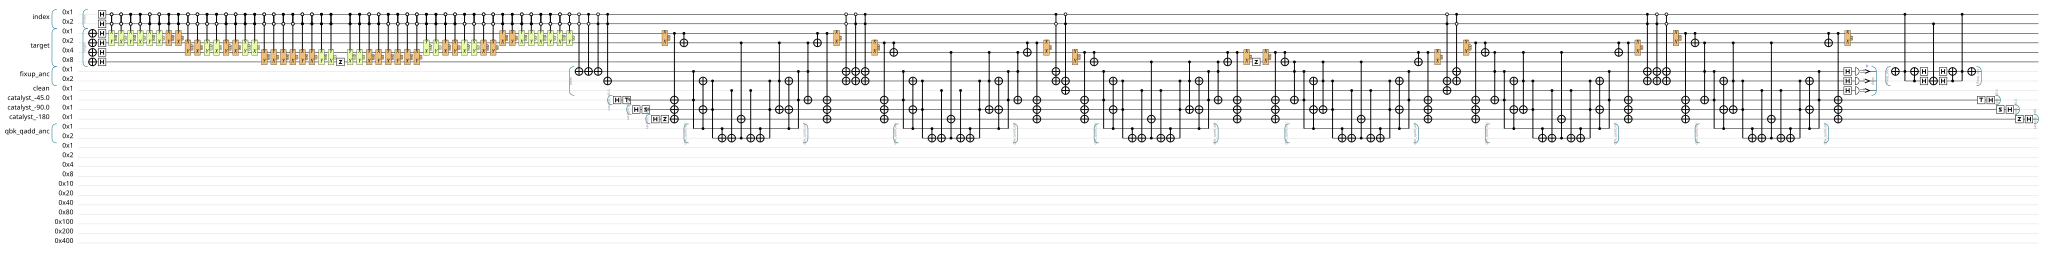

In [3]:
adders = [("GivensRotationFusedAdder", GivensRotationFusedAdder), ("GivensRotationTwoAdders", GivensRotationTwoAdders)]

batches_config = 3
b_of_p = 3
rotation_qubrick = adders[0]

test_brno(batches_config, b_of_p, rotation_qubrick)